## Setup and Dependencies

In [1]:
import numpy as np
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar
from matplotlib import pyplot as plt
from fredapi import Fred
from dolo import *
import os
from statsmodels.regression.linear_model import OLS
from pandas_datareader import data as pdr
from statsmodels.tsa.filters.hp_filter import hpfilter
import yfinance as yf
import datetime as dt

## Model Setup

In [2]:
yaml_rbc = """
name: Real Business Cycle

symbols:

   exogenous: [e_z]
   states: [z, k]
   controls: [n, i]
   parameters: [beta, sigma, eta, chi, delta, alpha, rho, zbar, sig_z]

definitions: |
    y[t] = exp(z[t])*k[t]^alpha*n[t]^(1-alpha)
    c[t] = y[t] - i[t]
    rk[t] = alpha*y[t]/k[t]
    w[t] = (1-alpha)*y[t]/n[t]

equations:

    arbitrage: |
        chi*n[t]^eta*c[t]^sigma - w[t]                     ⟂ 0.0 <= n[t] <= inf
        1 - beta*(c[t]/c[t+1])^(sigma)*(1-delta+rk[t+1])   ⟂ -inf <= i[t] <= inf

    transition: |
        z[t] = rho*z[t-1] + e_z
        k[t] = (1-delta)*k[t-1] + i[t-1]

calibration:

    # parameters
    beta : 0.99
    phi: 1
    delta : 0.025
    alpha : 0.33
    rho : 0.8
    sigma: 5
    eta: 1
    sig_z: 0.016
    zbar: 0
    chi : w/c^sigma/n^eta
    c_i: 1.5
    c_y: 0.5
    e_z: 0.0
    n: 0.33
    z: zbar
    rk: 1/beta-1+delta
    w: (1-alpha)*exp(z)*(k/n)^(alpha)
    k: n/(rk/alpha)^(1/(1-alpha))
    y: exp(z)*k^alpha*n^(1-alpha)
    i: delta*k
    c: y - i
    V: log(c)/(1-beta)
    u: c^(1-sigma)/(1-sigma) - chi*n^(1+eta)/(1+eta)
    m: beta/c^sigma*(1-delta+rk)
    kss: 10

exogenous: !UNormal
    sigma: 0.01

domain:
    z: [-2*sig_z/(1-rho^2)^0.5,  2*sig_z/(1-rho^2)^0.5]
    k: [ kss*0.5, kss*1.5]

options:
    grid: !Cartesian
        n: [100, 100]
    discrete_choices: [n]
"""

file_path = "yamlDSGE/rbc.yaml"

os.makedirs(os.path.dirname(file_path), exist_ok=True)

with open(file_path, "w", encoding="utf-8") as f:
    f.write(yaml_rbc)

print(f"RBC model saved to {file_path}")

RBC model saved to yamlDSGE/rbc.yaml


## Model Execution

In [8]:
# gdp = pdr.DataReader("GDPC1", "fred", start=dt.date(1999, 12, 31), end=dt.date(2025, 9, 30))
# len(gdp)

In [9]:
# gdp = gdp.dropna()
# len(gdp)

In [10]:
# prod = pdr.DataReader("OPHNFB", "fred", start=dt.date(1999, 12, 31), end=dt.date(2025, 9, 30))
# len(prod)

In [11]:
# prod = prod.dropna()
# len(prod)

In [3]:
class Modifications():
    def __init__(self):
        self.months_in_quarter = 3

    def convert_years_to_quarters(self, length_years):
        return length_years * 4
    
    def convert_years_to_months(self, length_years):
        return length_years * 12

    def get_shifted_date(self, date_input, date_offset_months, direction="backwards"):
        if direction == "backwards":
            date_offset_months *= -1
        
        shifted_date = (
            ((pd.tseries.offsets.BMonthBegin().rollback(date_input)) + pd.tseries.offsets.DateOffset(months=date_offset_months)) 
            + pd.tseries.offsets.BMonthEnd()
        ).date()
    
        return shifted_date
    
    def add_buffer_for_start_offset(self, offset_months):
        return offset_months + 3 # Productivity and GDP starts need a buffer of 1 quarter, as the quarterly index is as of the start of the quarter rather than the end of the quarter

In [4]:
class Data(Modifications):
    def  __init__(self, data_length_years_max, horizon_start_in, horizon_end_in):
        Modifications.__init__(self)
        self.data_length_years_max = data_length_years_max
        self.data_length_quarters_max = self.convert_years_to_quarters(self.data_length_years_max)
        self.data_length_months_max = self.convert_years_to_months(self.data_length_years_max)
        
        self.horizon_start_in = horizon_start_in
        self.horizon_end_in = horizon_end_in
        self.horizon_start = self.convert_str_date_to_dt(self.horizon_start_in)
        self.horizon_end = self.convert_str_date_to_dt(self.horizon_end_in)
        self.date_start_gdp = self.get_shifted_date(self.horizon_start, self.add_buffer_for_start_offset(self.data_length_months_max)) # Data starts 10 years prior to window start
        self.date_start_prod = self.get_shifted_date(self.date_start_gdp, self.months_in_quarter) # Data starts one quarter prior to GDP data for next-period forecasting
        self.date_end_prod = self.get_shifted_date(self.horizon_end, self.months_in_quarter) # Data ends one quarter before window end as the final forecast must be of the window end date
        # self.horizon_start_prod = self.get_shifted_date(self.horizon_start, self.months_in_quarter) # Window starts one quarter prior to GDP data for next-period forecasting
        self.date_end_asset = self.get_shifted_date(self.horizon_end, self.months_in_quarter, "forwards") + pd.tseries.offsets.DateOffset(days=1) # end date in yahoo finance query is exclusive so extend by 1 day

        self.prod = self.pull_data_productivity()
        self.gdp = self.pull_data_gdp()
        self.asset_sp500 = self.pull_asset("^GSPC")
        self.asset_dow = self.pull_asset("^DJI")
        self.holidays = self.get_holidays()

    def convert_str_date_to_dt(self, date_in):
        return dt.date(int(date_in[:4]), int(date_in[5:7]), int(date_in[8:]))

    def convert_fred_index_to_qe(self, index_dates):
        return [date_i.date() for date_i in index_dates.date + pd.tseries.offsets.BQuarterEnd()]
    
    # Non-farm business labor productivity index
    def pull_data_productivity(self):
        prod = pdr.DataReader("OPHNFB", "fred", start=self.date_start_prod, end=self.date_end_prod)
        prod_index_name = prod.index.name
        prod.index = self.convert_fred_index_to_qe(prod.index)
        prod.index.name = prod_index_name
        prod = prod.dropna()
        
        return prod

    # Real GDP
    def pull_data_gdp(self):
        gdp = pdr.DataReader("GDPC1", "fred", start=self.date_start_gdp, end=self.horizon_end)
        gdp_index_name = gdp.index.name
        gdp.index = self.convert_fred_index_to_qe(gdp.index)
        gdp.index.name = gdp_index_name
        gdp = gdp.dropna()
        
        return gdp

    # Asset
    def pull_asset(self, ticker):
        asset_ser = yf.Ticker(ticker).history(start=self.horizon_start, end=self.date_end_asset)["Close"]

        asset_ser_name = asset_ser.index.name
        asset_ser.index = asset_ser.index.date
        asset_ser.index.name = asset_ser_name
        
        return asset_ser

    def get_holidays(self):
        cal_us = USFederalHolidayCalendar()
        holidays = cal_us.holidays(start=self.horizon_start, end=self.date_end_asset) # holiday date range for the window considered for the country linked to the asset

        return holidays

In [6]:
class Model(Modifications):
    def __init__(self, model_type, prod, gdp, assets, asset_names, holidays):
        Modifications.__init__(self)
        self.model_type = model_type
        self.model = self.load_model(self.model_type)
        self.prod = prod
        self.gdp = gdp
        self.assets = assets
        self.asset_names = asset_names
        self.holidays = holidays

        self.latest_quarters_dict = {}
        self.output_forecasts_dict = {}
        self.latest_quarters_gdp_dict = {}
        self.outputs_realised_dict = {}

    def load_model(self, model_type):
        model = yaml_import(f"yamlDSGE/{model_type}.yaml")

        return model

    def generate_signals(self, data_length_years, window_gdp_start, window_gdp_end, leverage, double_down, show_irf=False):
        assert len(self.prod) == len(self.gdp)

        data_length_quarters = self.convert_years_to_quarters(data_length_years)
        data_length_months = self.convert_years_to_months(data_length_years)

        # Check the window and preceding data are in bounds of overall productivity and GDP data
        earliest_datapoint_gdp = self.get_shifted_date(window_gdp_start, data_length_months)
        assert earliest_datapoint_gdp >= self.gdp.index[0], f"Outside bounds: {earliest_datapoint_gdp} !>= {self.gdp.index[0]}"

        earliest_datapoint_prod = self.get_shifted_date(earliest_datapoint_gdp, self.months_in_quarter)
        assert earliest_datapoint_prod >= self.prod.index[0], f"Outside bounds: {earliest_datapoint_prod} !>= {self.prod.index[0]}"

        assert window_gdp_end <= self.gdp.index[-1], f"Outside bounds: {window_gdp_end} !<= {self.gdp.index[-1]}"
        
        latest_datapoint_prod = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        assert latest_datapoint_prod <= self.prod.index[-1], f"Outside bounds: {latest_datapoint_prod} !<= {self.prod.index[-1]}"

        # Generate output forecasts
        prod_index_name = self.prod.index.name
        window_prod_start = self.get_shifted_date(window_gdp_start, self.months_in_quarter)
        window_prod_end = self.get_shifted_date(window_gdp_end, self.months_in_quarter)
        window_prod = self.prod[(self.prod.index >= window_prod_start) & (self.prod.index <= window_prod_end)]
        print("\nwindow_prod:\n")
        print(window_prod)
        
        latest_quarters = []
        output_forecasts = []
        for q in window_prod.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_dict.keys():
                latest_quarters.append(self.latest_quarters_dict[q_key])
                output_forecasts.append(self.output_forecasts_dict[q_key])
                print(f"Reading IRF forecast as of {q} with {data_length_years} years of calibration")
            else:
                prod_data = self.prod[(self.prod.index >= self.get_shifted_date(q, data_length_months)) & (self.prod.index <= q)]
                assert len(prod_data.index) == data_length_quarters + 1
                
                prod_cycle, prod_trend = hpfilter(np.log(prod_data), lamb=1600)
                # prod_cycle.plot()
                
                a_hat = prod_cycle
                a = a_hat
                a_lag = a.shift()
                
                y = a.iloc[1:]
                X = a_lag.iloc[1:].values
                
                ar1 = OLS(y.values, X).fit()
                
                rho_hat = ar1.params[0]
                print(f"Estimated rho: {rho_hat:.3f}")
            
                eps_hat = pd.Series(
                    ar1.resid,
                    index=y.index,
                    name="tfp_shock"
                )
                # eps_hat.plot()
                
                latest_quarter = eps_hat.index[-1]
                latest_shock = eps_hat.iloc[-1]
                
                print(f"Estimated TFP shock for {latest_quarter}: {latest_shock:.4f}")
            
                # Set the estimated TFP persistence coefficient as a calibrated parameter in the model
                self.model.set_calibration(rho=rho_hat)
                # print(model.calibration.flat)
            
                #dr = time_iteration(model)
                dr = perturb(self.model, order=1)
                
                irf = response(self.model, dr, 'e_z', T=10, impulse=float(latest_shock))

                if show_irf == True:
                    plt.figure(figsize=(8,4))
                    plt.subplot(221)
                    plt.plot(irf.sel(V='z'))
                    plt.title('Productivity')
                    plt.grid()
                    plt.subplot(222)
                    plt.plot(irf.sel(V='y'))
                    plt.title('Output')
                    plt.grid()
                    plt.subplot(223)
                    plt.plot(irf.sel(V='i'))
                    plt.title('Investment')
                    plt.grid()
                    plt.subplot(224)
                    plt.plot(irf.sel(V='c'))
                    plt.title('Consumption')
                    plt.grid()
                    plt.tight_layout()
                    plt.show()
                
                irf_output = np.array(irf.sel(V='y'))
                
                irf_output = [(x - 1) for x in irf_output]
                output_forecast = irf_output[2]
                print(f"Next period IRF forecast as of {latest_quarter}: {output_forecast:.5f}")
                
                self.latest_quarters_dict[q_key] = latest_quarter
                latest_quarters.append(latest_quarter)
                self.output_forecasts_dict[q_key] = output_forecast
                output_forecasts.append(output_forecast)
        
        output_forecasts_ser = pd.Series(output_forecasts, index=latest_quarters) # Next period forecasts, e.g. 2025Q2 is forecast of 2025Q3
        output_forecasts_ser.name = "output_forecast"
        output_forecasts_ser.index.name = prod_index_name
        output_forecasts_df = output_forecasts_ser.to_frame()
        # output_forecasts_df

        # Obtain realised output
        gdp_index_name = self.gdp.index.name
        window_gdp = self.gdp[(self.gdp.index >= window_gdp_start) & (self.gdp.index <= window_gdp_end)]
        print("\window_gdp:\n")
        print(window_gdp)
        
        latest_quarters_gdp = []
        outputs_realised = []
        for q in window_gdp.index:
            q_key = str(q) + "_" + str(data_length_years) + "y"
            if q_key in self.latest_quarters_gdp_dict.keys():
                latest_quarters_gdp.append(self.latest_quarters_gdp_dict[q_key])
                outputs_realised.append(self.outputs_realised_dict[q_key])
                print(f"Reading realised value as of {q} with {data_length_years} years of calibration")
            else:
                gdp_data = self.gdp[(self.gdp.index >= self.get_shifted_date(q, data_length_months)) & (self.gdp.index <= q)]
                assert len(gdp_data.index) == data_length_quarters + 1
            
                gdp_cycle, gdp_trend = hpfilter(np.log(gdp_data), lamb=1600)
                output_gap = gdp_cycle
                latest_quarter_gdp = output_gap.last_valid_index()
                output_realised = output_gap.iloc[-1]
                print(f"Current period realised value as of {latest_quarter_gdp}: {output_realised:.5f}")
                
                self.latest_quarters_gdp_dict[q_key] = latest_quarter_gdp
                latest_quarters_gdp.append(latest_quarter_gdp)
                self.outputs_realised_dict[q_key] = output_realised
                outputs_realised.append(output_realised)
        
        outputs_realised_ser = pd.Series(outputs_realised, index=latest_quarters_gdp) # Realised GDP growth after HP filter, e.g. 2025Q3 reflects GDP growth in 2025Q3
        outputs_realised_ser.name = "output_realised"
        outputs_realised_ser.index.name = gdp_index_name
        outputs_realised_df = outputs_realised_ser.to_frame()
        # outputs_realised_df

        # Prepare signals
        signals_init = outputs_realised_df.join(output_forecasts_df, how="outer")
        output_forecasts_mod_df = signals_init.shift()[["output_forecast"]].dropna()
        signals = outputs_realised_df.join(output_forecasts_mod_df)
        
        def determine_pos(row, direction, leverage):
            if row["output_forecast"] > row["output_realised"]:
                pos = 1
            elif row["output_forecast"] < row["output_realised"]:
                pos = -1
            else:
                pos = 0
        
            if direction == "mr":
                pos *= -1
            
            return pos * leverage
        
        signals["pos_mom"] = signals.apply(determine_pos, axis=1, direction="mom", leverage=leverage)
        signals["pos_mr"] = signals.apply(determine_pos, axis=1, direction="mr", leverage=leverage)
        
        if double_down == True:
            signals_lagged = signals[["pos_mom", "pos_mr"]].shift().fillna(0)
            signals_lagged = signals_lagged.rename(columns={"pos_mom": "pos_mom_prev", "pos_mr": "pos_mr_prev"})
            signals = signals.join(signals_lagged)
            
            signals["double_down_scalar_mom"] = signals.apply(lambda row: 2 if row["pos_mom"] == row["pos_mom_prev"] else 1, axis=1)
            signals["double_down_scalar_mr"] = signals.apply(lambda row: 2 if row["pos_mr"] == row["pos_mr_prev"] else 1, axis=1)
        else:
            signals["double_down_scalar_mom"] = 1
            signals["double_down_scalar_mr"] = 1

        signals["pos_final_mom"] = signals["pos_mom"] * signals["double_down_scalar_mom"]
        signals["pos_final_mr"] = signals["pos_mr"] * signals["double_down_scalar_mr"]
        
        return signals

    def summarise_results(self, pos, pnl, strategy_type, asset_name):
        # fig_pos, ax_pos = plt.subplots(figsize=(12, 6))
        # pos.plot(ax=ax_pos, grid=True)
        # plt.close(fig_pos)
        
        # fig_pnl_cumsum, ax_pnl_cumsum = plt.subplots(figsize=(12, 6))
        # pnl.cumsum().plot(ax=ax_pnl_cumsum, grid=True)
        # plt.close(fig_pnl_cumsum)

        pnl_sum = pnl.sum()
        pnl_mean = pnl.mean()
        pnl_std = pnl.std()
        sr_daily = pnl_mean / pnl_std
        sr_annual = sr_daily * np.sqrt(252)

        results = {
            # "fig_pos_" + strategy_type + "_" + asset_name: fig_pos,
            # "fig_pnl_cumsum_" + strategy_type + "_" + asset_name: fig_pnl_cumsum,
            "pos_" + strategy_type + "_" + asset_name: pos,
            "pnl_cumsum_" + strategy_type + "_" + asset_name: pnl.cumsum(),
            "pnl_sum_" + strategy_type + "_" + asset_name: pnl_sum,
            "pnl_mean_" + strategy_type + "_" + asset_name: pnl_mean,
            "pnl_std_" + strategy_type + "_" + asset_name: pnl_std,
            "sr_daily_" + strategy_type + "_" + asset_name: sr_daily,
            "sr_annual_" + strategy_type + "_" + asset_name: sr_annual
        }
        
        return results
    
    def run_strategy(self, signals, signal_lag, window_gdp_start, window_gdp_end, show_pos=False):
        # Delay signals by a particular number of business days to account for lag in GDP and productivity data availability
        signals_actual = signals[["output_realised", "output_forecast", "pos_final_mom", "pos_final_mr"]]
        signals_actual.index += pd.offsets.CustomBusinessDay(n=signal_lag, holidays=self.holidays)
        
        date_end_asset = self.get_shifted_date(window_gdp_end, self.months_in_quarter, "forwards")
        results = {"signals_actual": signals_actual}
        for i, asset in enumerate(self.assets):
            asset_ser = asset[(asset.index >= window_gdp_start) & (asset.index <= date_end_asset)]
            asset_ret_ser = asset_ser.pct_change()
            asset_ret_ser.name = "Return"

            asset_ret_df = asset_ret_ser.to_frame()
            asset_ret_df = asset_ret_df.join(signals_actual[["pos_final_mom", "pos_final_mr"]]).ffill().fillna(0)
            if show_pos:
                asset_ret_df.plot(figsize=(12, 6), grid=True)

            asset_ret_lagged_df = asset_ret_df[["pos_final_mom", "pos_final_mr"]].shift()
            pnl = asset_ret_df[["Return"]].join(asset_ret_lagged_df).fillna(0)

            cost_per_trade = 0.0001 # 1 bp
            cost = abs(pnl[["pos_final_mom", "pos_final_mr"]].diff().fillna(0).rename(columns={"pos_final_mom": "cost_mom", "pos_final_mr": "cost_mr"})) * 0.5 * cost_per_trade
            pnl_full = pnl.join(cost)
            
            pnl_full["pnlg_mom"] = pnl_full["Return"] * pnl_full["pos_final_mom"]
            pnl_full["pnln_mom"] = pnl_full["pnlg_mom"] - pnl_full["cost_mom"]
            pnl_full["pnlg_mr"] = pnl_full["Return"] * pnl_full["pos_final_mr"]
            pnl_full["pnln_mr"] = pnl_full["pnlg_mr"] - pnl_full["cost_mr"]

            results_momg = self.summarise_results(asset_ret_df["pos_final_mom"], pnl_full["pnlg_mom"], "momg", self.asset_names[i])
            results_momn = self.summarise_results(asset_ret_df["pos_final_mom"], pnl_full["pnln_mom"], "momn", self.asset_names[i])
            results_mrg = self.summarise_results(asset_ret_df["pos_final_mr"], pnl_full["pnlg_mr"], "mrg", self.asset_names[i])
            results_mrn = self.summarise_results(asset_ret_df["pos_final_mr"], pnl_full["pnln_mr"], "mrn", self.asset_names[i])
            results = results | results_momg | results_momn | results_mrg | results_mrn

        return results

In [7]:
class BuyAndHold(Modifications):
    def __init__(self, assets, asset_names):
        Modifications.__init__(self)
        self.assets = assets
        self.asset_names = asset_names

    def run_strategy(self, window_start, window_end):
        date_end_asset = self.get_shifted_date(window_end, self.months_in_quarter, "forwards")
        results = {"signals_actual": 1}
        for i, asset in enumerate(self.assets):
            asset_ser = asset[(asset.index >= window_start) & (asset.index <= date_end_asset)]
    
            asset_ret_ser = asset_ser.pct_change().fillna(0)
            asset_ret_ser.name = "Return"
            pnl = asset_ret_ser
            
            # fig_pnl_cumsum, ax_pnl_cumsum = plt.subplots(figsize=(12, 6))
            # pnl.cumsum().plot(ax=ax_pnl_cumsum, grid=True)
            # plt.close(fig_pnl_cumsum)
    
            pnl_sum = pnl.sum()
            pnl_mean = pnl.mean()
            pnl_std = pnl.std()
            sr_daily = pnl_mean / pnl_std
            sr_annual = sr_daily * np.sqrt(252)
            
            results_bh = {
                # "fig_pnl_cumsum_" + self.asset_names[i]: fig_pnl_cumsum,
                "pnl_cumsum_" + self.asset_names[i]: pnl.cumsum(),
                "pnl_sum_" + self.asset_names[i]: pnl_sum,
                "pnl_mean_" + self.asset_names[i]: pnl_mean,
                "pnl_std_" + self.asset_names[i]: pnl_std,
                "sr_daily_" + self.asset_names[i]: sr_daily,
                "sr_annual_" + self.asset_names[i]: sr_annual
            }

            results = results | results_bh

        return results

In [8]:
data_10y_19991231_20250930 = Data(10, "1999-12-31", "2025-09-30")

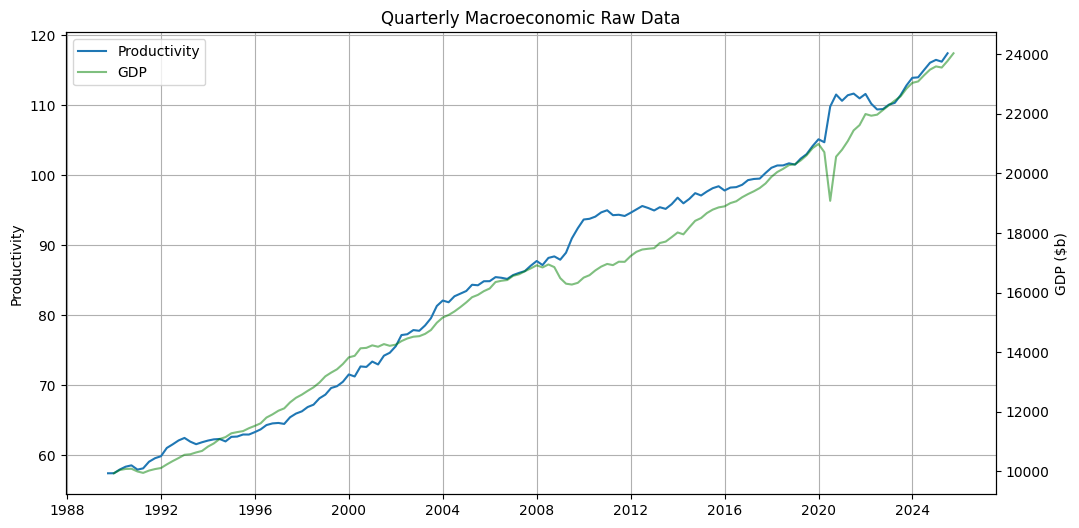

In [15]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    data_10y_19991231_20250930.prod,
    label="Productivity"
)

ax1.set_ylabel("Productivity")
ax1.grid(True)

# Secondary y-axis: positions
ax2 = ax1.twinx()

ax2.plot(
    data_10y_19991231_20250930.gdp,
    color="green",
    alpha=0.5,
    label="GDP"
)

ax2.set_ylabel("GDP ($b)")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Quarterly Macroeconomic Raw Data")
plt.show()

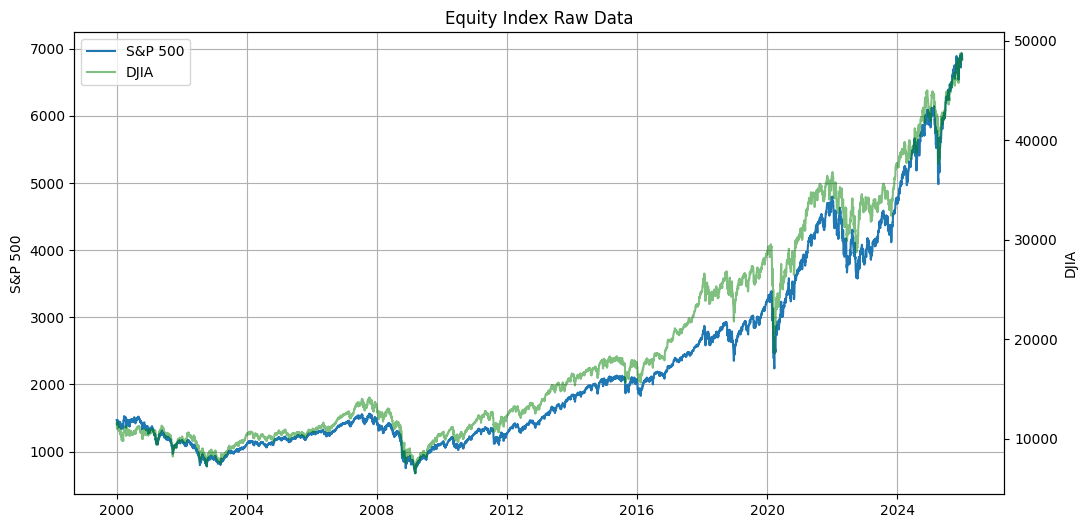

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    data_10y_19991231_20250930.asset_sp500,
    label="S&P 500"
)

ax1.set_ylabel("S&P 500")
ax1.grid(True)

# Secondary y-axis: positions
ax2 = ax1.twinx()

ax2.plot(
    data_10y_19991231_20250930.asset_dow,
    color="green",
    alpha=0.5,
    label="DJIA"
)

ax2.set_ylabel("DJIA")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Equity Index Raw Data")
plt.show()

In [9]:
# rbc = Model(
#     "rbc", 
#     data_20y_19991231_20250930.prod, 
#     data_20y_19991231_20250930.gdp, 
#     data_20y_19991231_20250930.asset,
#     data_20y_19991231_20250930.holidays
# )

In [13]:
# rbc = Model(
#     "rbc", 
#     data_10y_19991231_20250930.prod, 
#     data_10y_19991231_20250930.gdp, 
#     [data_10y_19991231_20250930.asset_sp500],
#     ["SP"],
#     data_10y_19991231_20250930.holidays
# )

# # signals = rbc.generate_signals(10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), 1, False, show_irf=True)
# signals = rbc.generate_signals(10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), 1, False)

In [14]:
# # strategy = rbc.run_strategy(signals, 10, dt.date(1999, 12, 31), dt.date(2025, 9, 30), show_pos=True)
# strategy = rbc.run_strategy(signals, 10, dt.date(1999, 12, 31), dt.date(2025, 9, 30))

In [15]:
# signals

In [16]:
# signals["pos_final_mr"].plot()

In [17]:
# strategy

In [18]:
# strategy.keys()

In [19]:
# strategy["pnl_sum_momg_SP"]

In [20]:
# strategy["pnl_sum_momn_SP"]

In [21]:
# strategy["fig_pnl_cumsum_momg_SP"]

In [22]:
# strategy["fig_pnl_cumsum_momn_SP"]

In [23]:
# plt.plot(strategy["pos_momg_SP"])

In [24]:
# plt.plot(strategy["pnl_cumsum_mrg_SP"])
# plt.plot(strategy["pnl_cumsum_mrn_SP"])
# plt.show()

In [25]:
# plt.close()

In [26]:
model_types = ["rbc"]
data_lengths = [5, 10, 20]
windows = [
    [dt.date(1999, 12, 31), dt.date(2025, 9, 30)],
    [dt.date(1999, 12, 31), dt.date(2007, 12, 31)],
    [dt.date(2007, 12, 31), dt.date(2009, 12, 31)],
    [dt.date(2009, 12, 31), dt.date(2019, 12, 31)],
    [dt.date(2019, 12, 31), dt.date(2022, 12, 31)],
    [dt.date(2022, 12, 31), dt.date(2025, 9, 30)],
]
signal_lags = [10, 20, 30]
leverage_cases = [1, 2]
double_down_cases = [False, True]

results = {}
for model_type in model_types:
    rbc = Model(
        model_type, 
        data_10y_19991231_20250930.prod, 
        data_10y_19991231_20250930.gdp, 
        [data_10y_19991231_20250930.asset_sp500, data_10y_19991231_20250930.asset_dow],
        ["SP", "DOW"],
        data_10y_19991231_20250930.holidays
    )

    bh = BuyAndHold(
        [data_10y_19991231_20250930.asset_sp500, data_10y_19991231_20250930.asset_dow],
        ["SP", "DOW"]
    )

    for window in windows:
        window_str = str(window[0]) + "_" + str(window[1])
        results[window_str] = {}
    
        for data_length in data_lengths:
            for signal_lag in signal_lags:
                for leverage in leverage_cases:
                    for double_down in double_down_cases:
                        if not ((data_length == 20) & (window[0] < dt.date(2009, 12, 31))): # GDP data is unavailable before 1989-12-29 so avoid sourcing data before then
                            signals = rbc.generate_signals(data_length, window[0], window[1], leverage, double_down)
                            strategy = rbc.run_strategy(signals, signal_lag, window[0], window[1])
                            
                            key = model_type + "_" + str(data_length) + "cal_" + window_str + "_" + str(signal_lag) + "lag"
                            if leverage > 1:
                                key += "_" + str(leverage) + "lev"
                            if double_down == True:
                                key += "_dd"
                            
                            results[window_str][key] = {"signals": signals, "strategy": strategy}

        strategy_bh = bh.run_strategy(window[0], window[1])
        
        key_bh = "bh_" + window_str
        results[window_str][key_bh] = {"strategy": strategy_bh}


window_prod:

             OPHNFB
DATE               
1999-09-30   70.469
1999-12-31   71.516
2000-03-31   71.222
2000-06-30   72.657
2000-09-29   72.587
...             ...
2024-06-28  114.990
2024-09-30  116.035
2024-12-31  116.445
2025-03-31  116.187
2025-06-30  117.385

[104 rows x 1 columns]
Estimated rho: 0.746
Estimated TFP shock for 1999-09-30: 0.0038
10 [0.00378041]
Next period IRF forecast as of 1999-09-30: 0.00004
Estimated rho: 0.716
Estimated TFP shock for 1999-12-31: 0.0089
10 [0.00891529]
Next period IRF forecast as of 1999-12-31: 0.00697
Estimated rho: 0.586
Estimated TFP shock for 2000-03-31: -0.0067
10 [-0.00668182]
Next period IRF forecast as of 2000-03-31: -0.01405
Estimated rho: 0.461
Estimated TFP shock for 2000-06-30: 0.0107
10 [0.01069896]
Next period IRF forecast as of 2000-06-30: 0.01003
Estimated rho: 0.407
Estimated TFP shock for 2000-09-29: -0.0037
10 [-0.00365668]
Next period IRF forecast as of 2000-09-29: -0.01004
Estimated rho: 0.365
Estimated TFP shock

In [27]:
# results

In [28]:
main_results_sorted = {}

for window in windows:
    window_str = str(window[0]) + "_" + str(window[1])
    main_results_sorted[window_str] = {}
    
    pnls_spg = []
    pnls_spn = []
    srs_spg = []
    srs_spn = []
    pnls_dowg = []
    pnls_down = []
    srs_dowg = []
    srs_down = []
    
    for strategy in results[window_str].keys():
        if "bh" in strategy:
            pnls_spg.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_SP"]])
            pnls_spn.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_SP"]]) # Assumed g = n for BH
            srs_spg.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_SP"]])
            srs_spn.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_SP"]]) # Assumed g = n for BH
            
            pnls_dowg.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_DOW"]])
            pnls_down.append([strategy, results[window_str][strategy]["strategy"]["pnl_sum_DOW"]]) # Assumed g = n for BH
            srs_dowg.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_DOW"]])
            srs_down.append([strategy, results[window_str][strategy]["strategy"]["sr_annual_DOW"]]) # Assumed g = n for BH
        else:
            pnls_spg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["pnl_sum_momg_SP"]])
            pnls_spn.append([strategy + "_momn", results[window_str][strategy]["strategy"]["pnl_sum_momn_SP"]])
            pnls_spg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["pnl_sum_mrg_SP"]])
            pnls_spn.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["pnl_sum_mrn_SP"]])
            srs_spg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["sr_annual_momg_SP"]])
            srs_spn.append([strategy + "_momn", results[window_str][strategy]["strategy"]["sr_annual_momn_SP"]])
            srs_spg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["sr_annual_mrg_SP"]])
            srs_spn.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["sr_annual_mrn_SP"]])

            pnls_dowg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["pnl_sum_momg_DOW"]])
            pnls_down.append([strategy + "_momn", results[window_str][strategy]["strategy"]["pnl_sum_momn_DOW"]])
            pnls_dowg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["pnl_sum_mrg_DOW"]])
            pnls_down.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["pnl_sum_mrn_DOW"]])
            srs_dowg.append([strategy + "_momg", results[window_str][strategy]["strategy"]["sr_annual_momg_DOW"]])
            srs_down.append([strategy + "_momn", results[window_str][strategy]["strategy"]["sr_annual_momn_DOW"]])
            srs_dowg.append([strategy + "_mrg", results[window_str][strategy]["strategy"]["sr_annual_mrg_DOW"]])
            srs_down.append([strategy + "_mrn", results[window_str][strategy]["strategy"]["sr_annual_mrn_DOW"]])
    
    main_results_sorted[window_str]["pnls_spg_sorted"] = sorted(pnls_spg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["pnls_spn_sorted"] = sorted(pnls_spn, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_spg_sorted"] = sorted(srs_spg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_spn_sorted"] = sorted(srs_spn, key=lambda x: x[1], reverse=True)
    
    main_results_sorted[window_str]["pnls_dowg_sorted"] = sorted(pnls_dowg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["pnls_down_sorted"] = sorted(pnls_down, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_dowg_sorted"] = sorted(srs_dowg, key=lambda x: x[1], reverse=True)
    main_results_sorted[window_str]["srs_down_sorted"] = sorted(srs_down, key=lambda x: x[1], reverse=True)

In [29]:
main_results_sorted.keys()

dict_keys(['1999-12-31_2025-09-30', '1999-12-31_2007-12-31', '2007-12-31_2009-12-31', '2009-12-31_2019-12-31', '2019-12-31_2022-12-31', '2022-12-31_2025-09-30'])

In [30]:
main_results_sorted["1999-12-31_2025-09-30"]["pnls_spn_sorted"]

[['rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd_mrn', 3.9690539941841454],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_2lev_dd_mrn', 3.6883771535339327],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_2lev_dd_mrn', 3.2013547049536006],
 ['rbc_5cal_1999-12-31_2025-09-30_20lag_2lev_dd_mrn', 2.8851227459772106],
 ['rbc_5cal_1999-12-31_2025-09-30_10lag_2lev_dd_mrn', 2.6306018798408393],
 ['rbc_10cal_1999-12-31_2025-09-30_10lag_2lev_dd_mrn', 2.4691099156563503],
 ['rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_mrn', 2.3221963552108837],
 ['bh_1999-12-31_2025-09-30', 2.0262566792516465],
 ['rbc_10cal_1999-12-31_2025-09-30_30lag_dd_mrn', 1.9845269970920727],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_2lev_mrn', 1.9604817727863253],
 ['rbc_5cal_1999-12-31_2025-09-30_30lag_dd_mrn', 1.8441885767669663],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_2lev_mrn', 1.836818941006284],
 ['rbc_10cal_1999-12-31_2025-09-30_20lag_dd_mrn', 1.6006773524768003],
 ['rbc_5cal_1999-12-31_2025-09-30_20lag_dd_mrn', 1.4425613729886053

<function matplotlib.pyplot.show(close=None, block=None)>

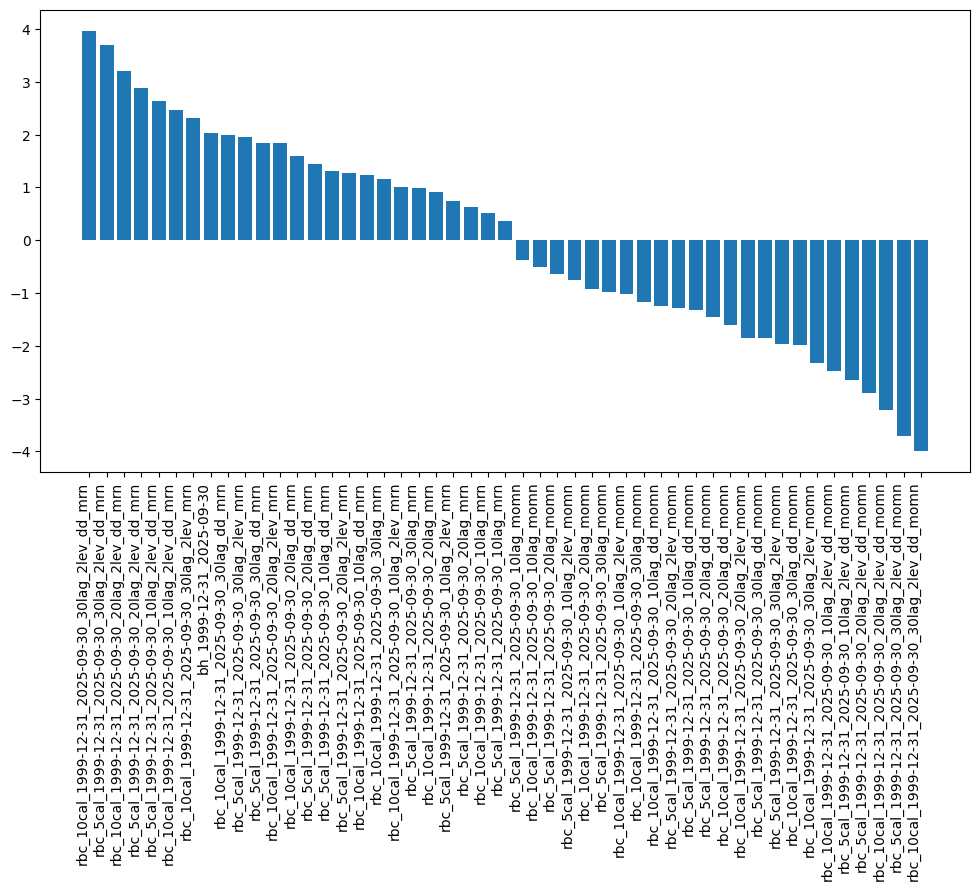

In [31]:
data_bar = main_results_sorted["1999-12-31_2025-09-30"]["pnls_spn_sorted"]
labels = [row[0] for row in data_bar]
values = [row[1] for row in data_bar]

plt.figure(figsize=(12, 6))
plt.bar(labels, values)

plt.xticks(rotation=90, ha='right')

plt.show

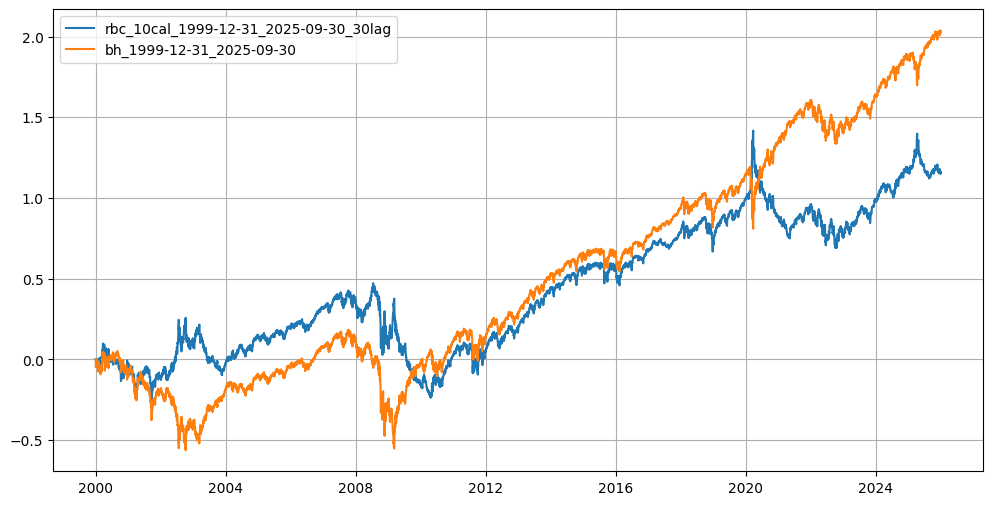

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag"
)
plt.plot(
    results["1999-12-31_2025-09-30"]["bh_1999-12-31_2025-09-30"]["strategy"]["pnl_cumsum_SP"],
    label="bh_1999-12-31_2025-09-30"
)
plt.grid(True)
plt.legend()

plt.show()

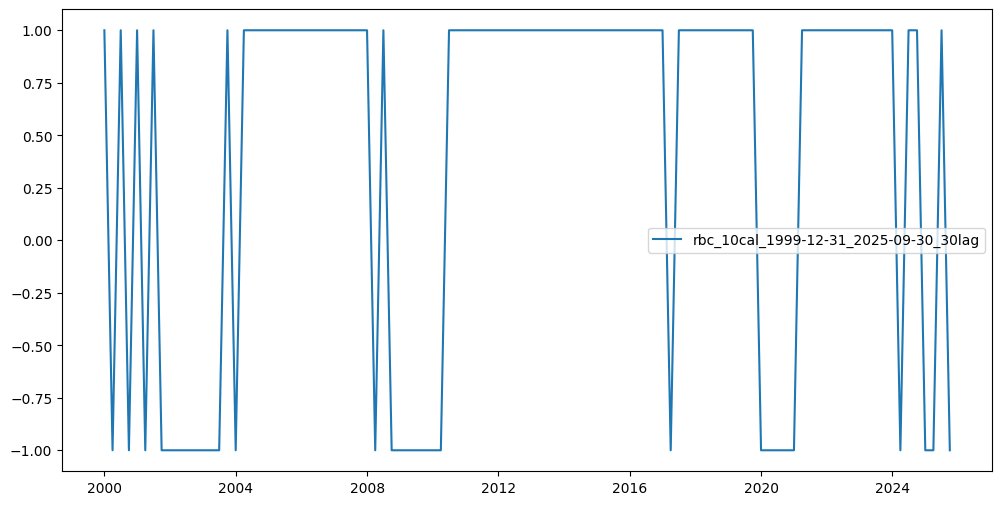

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["signals"]["pos_final_mr"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag"
)
# plt.grid(True)
plt.legend()

plt.show()

In [34]:
results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["signals"]

,output_realised,output_forecast,pos_mom,pos_mr,double_down_scalar_mom,double_down_scalar_mr,pos_final_mom,pos_final_mr
DATE,,,,,,,,
1999-12-31,0.009403,0.000712,-1,1,1,1,-1,1
2000-03-31,0.001798,0.006943,1,-1,1,1,1,-1
2000-06-30,0.007257,-0.015021,-1,1,1,1,-1,1
2000-09-29,-0.002123,0.011726,1,-1,1,1,1,-1
2000-12-29,-0.005608,-0.012001,-1,1,1,1,-1,1
...,...,...,...,...,...,...,...,...
2024-09-30,0.003100,0.001564,-1,1,1,1,-1,1
2024-12-31,0.000410,0.002164,1,-1,1,1,1,-1
2025-03-31,-0.006721,-0.004246,1,-1,1,1,1,-1


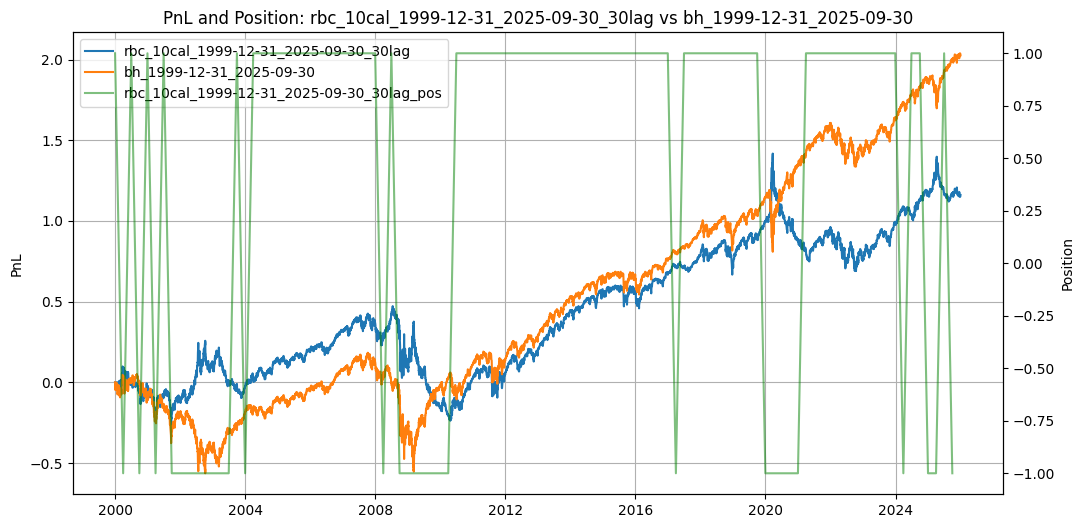

In [35]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["bh_1999-12-31_2025-09-30"]["strategy"]["pnl_cumsum_SP"],
    label="bh_1999-12-31_2025-09-30"
)

ax1.set_ylabel("PnL")
ax1.grid(True)

# Secondary y-axis: positions
ax2 = ax1.twinx()

ax2.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["signals"]["pos_final_mr"],
    color="green",
    alpha=0.5,
    label="rbc_10cal_1999-12-31_2025-09-30_30lag_pos"
)

ax2.set_ylabel("Position")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("PnL and Position: rbc_10cal_1999-12-31_2025-09-30_30lag vs bh_1999-12-31_2025-09-30")
plt.show()

In [36]:
def parse_strategy(strategy_name, metric, metric_name):
    # Buy-and-hold special case
    if strategy_name.startswith("bh_"):
        parts = strategy_name.split("_")

        return {
            "Model": "BH",
            "Data Length": "N/A",
            "Horizon": f"{parts[1]}_{parts[2]}",
            "Signal Lag": "N/A",
            "Leverage": 1,
            "Double Down": "No",
            "Strategy Type": "N/A",
            metric_name: round(metric, 2),
        }

    parts = strategy_name.split("_")

    model = parts[0].upper()
    data_length = parts[1].replace("cal", "y")
    horizon = f"{parts[2]}_{parts[3]}"

    leverage = 1
    double_down = "No"

    strategy_type = None
    signal_lag = None

    for token in parts[4:]:
        if token.endswith("lag"):
            signal_lag = token.replace("lag", "b")
        elif token.endswith("lev"):
            leverage = int(token.replace("lev", ""))
        elif token == "dd":
            double_down = "Yes"
        elif token in ["mrn", "mrg"]:
            strategy_type = "MR"
        elif token in ["momn", "momg"]:
            strategy_type = "MOM"

    return {
        "Model": model,
        "Data Length": data_length,
        "Horizon": horizon,
        "Signal Lag": signal_lag,
        "Leverage": leverage,
        "Double Down": double_down,
        "Strategy Type": strategy_type,
        metric_name: round(metric, 2),
    }

In [37]:
results_full_pnls_spn = main_results_sorted["1999-12-31_2025-09-30"]["pnls_spn_sorted"]
results_full_pnls_spg = main_results_sorted["1999-12-31_2025-09-30"]["pnls_spg_sorted"]
results_full_srs_spn = main_results_sorted["1999-12-31_2025-09-30"]["srs_spn_sorted"]
results_full_srs_spg = main_results_sorted["1999-12-31_2025-09-30"]["srs_spg_sorted"]

In [38]:
results_full_pnls_spn_rows = [parse_strategy(strategy, metric, "Net PnL") for strategy, metric in results_full_pnls_spn]
results_full_pnls_spn_formatted = pd.DataFrame(results_full_pnls_spn_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])

results_full_pnls_spg_rows = [parse_strategy(strategy, metric, "Gross PnL") for strategy, metric in results_full_pnls_spg]
results_full_pnls_spg_formatted = pd.DataFrame(results_full_pnls_spg_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])

results_full_srs_spn_rows = [parse_strategy(strategy, metric, "Net SR") for strategy, metric in results_full_srs_spn]
results_full_srs_spn_formatted = pd.DataFrame(results_full_srs_spn_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])

results_full_srs_spg_rows = [parse_strategy(strategy, metric, "Gross SR") for strategy, metric in results_full_srs_spg]
results_full_srs_spg_formatted = pd.DataFrame(results_full_srs_spg_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])

# Optional: sort by Net PnL descending
# df = df.sort_values("Net PnL", ascending=False).reset_index(drop=True)

In [39]:
results_full_sp = results_full_pnls_spn_formatted.join(results_full_pnls_spg_formatted).join(results_full_srs_spn_formatted).join(results_full_srs_spg_formatted).reset_index()
#results_full_sp

In [40]:
results_comb_dict = {}

for asset in ["sp", "dow"]:
    results_comb_list = []
    
    for horizon in main_results_sorted.keys():
        results_pnls_n = main_results_sorted[horizon]["pnls_" + asset + "n_sorted"]
        results_pnls_n_rows = [parse_strategy(strategy, metric, "Net PnL") for strategy, metric in results_pnls_n]
        results_pnls_n_formatted = pd.DataFrame(results_pnls_n_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])
        
        results_pnls_g = main_results_sorted[horizon]["pnls_" + asset + "g_sorted"]
        results_pnls_g_rows = [parse_strategy(strategy, metric, "Gross PnL") for strategy, metric in results_pnls_g]
        results_pnls_g_formatted = pd.DataFrame(results_pnls_g_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])
        
        results_srs_n = main_results_sorted[horizon]["srs_" + asset + "n_sorted"]
        results_srs_n_rows = [parse_strategy(strategy, metric, "Net SR") for strategy, metric in results_srs_n]
        results_srs_n_formatted = pd.DataFrame(results_srs_n_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])
        
        results_srs_g = main_results_sorted[horizon]["srs_" + asset + "g_sorted"]
        results_srs_g_rows = [parse_strategy(strategy, metric, "Gross SR") for strategy, metric in results_srs_g]
        results_srs_g_formatted = pd.DataFrame(results_srs_g_rows).set_index(["Model", "Data Length", "Horizon", "Signal Lag", "Leverage", "Double Down", "Strategy Type"])
        
        results_comb = results_pnls_n_formatted.join(results_pnls_g_formatted).join(results_srs_n_formatted).join(results_srs_g_formatted).reset_index()
        results_comb_list.append(results_comb)
        results_comb.to_csv("results/summary_" + asset + "_" + horizon + ".csv", index=False)
    
    results_comb_dict[asset] = results_comb_list

### Gross and Net Performance

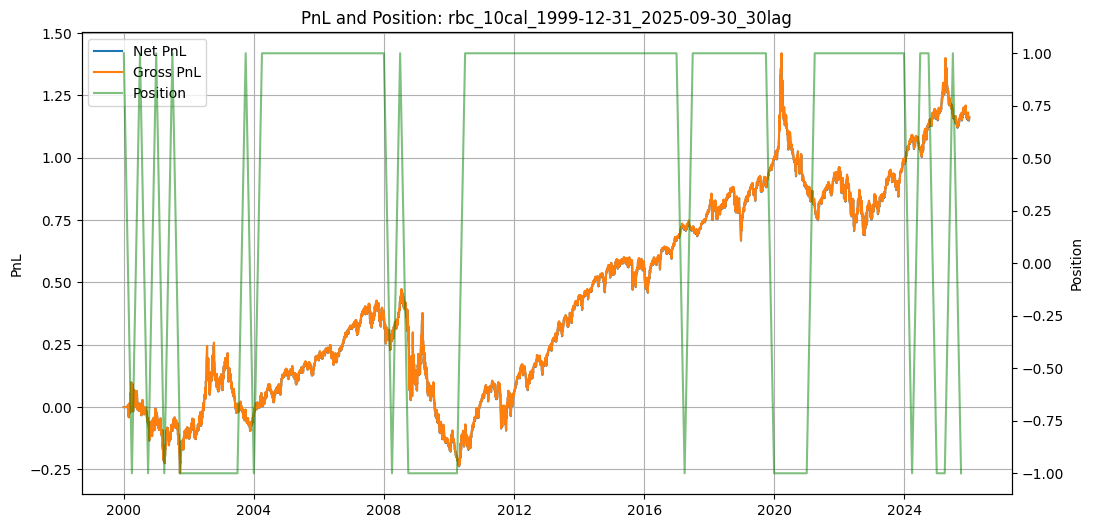

In [41]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="Net PnL"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrg_SP"],
    label="Gross PnL"
)

ax1.set_ylabel("PnL")
ax1.grid(True)

# Secondary y-axis: positions
ax2 = ax1.twinx()

ax2.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["signals"]["pos_final_mr"],
    color="green",
    alpha=0.5,
    label="Position"
)

ax2.set_ylabel("Position")

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("PnL and Position: rbc_10cal_1999-12-31_2025-09-30_30lag")
plt.show()

In [42]:
representative_pos = results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["signals"]["pos_final_mr"]
representative_pos_change = representative_pos.diff().fillna(0)
representative_pos_change_bin = representative_pos_change.apply(lambda x: 1 if x == 0 else 0).to_list()
pos_counts = []
pos_count = 0
stop = len(representative_pos_change_bin) - 1
for i, n in enumerate(representative_pos_change_bin):
    if n == 1:
        pos_count += 1
        if i == stop:
            pos_counts.append(pos_count)
    else:
        if pos_count > 0:
            pos_counts.append(pos_count)
        pos_count = 0
pos_counts

[1, 7, 15, 6, 26, 9, 4, 11, 1, 1]

In [43]:
len(representative_pos) # 104 quarters total

104

In [44]:
sum(pos_counts) # of which 81 in which pos fixed

81

In [45]:
changes = [n for n in representative_pos_change_bin if n == 0]
len(changes) # of which new pos

23

In [46]:
pos_counts_all = [int(n) for n in np.ones(len(changes))] + pos_counts
np.mean(pos_counts_all) # mean number of quarters a position is held

3.1515151515151514

In [47]:
position_changes_count_dict = {}
position_changes_perc_dict = {}
for strat in results["1999-12-31_2025-09-30"].keys():
    if "bh" not in strat:
        positions_diff = results["1999-12-31_2025-09-30"][strat]["strategy"]["signals_actual"]["pos_final_mom"].diff().fillna(0)
        position_changes = positions_diff[positions_diff != 0]
        position_changes_count = len(position_changes)
        position_changes_count_dict[strat] = position_changes_count

        daily_positions = results["1999-12-31_2025-09-30"][strat]["strategy"]["pos_momg_SP"]
        positions_total_count = len(daily_positions)
        
        position_changes_perc = round(position_changes_count / positions_total_count * 100, 2)
        position_changes_perc_dict[strat] = position_changes_perc

In [48]:
positions_total_count

6540

In [49]:
position_changes_df = pd.DataFrame([position_changes_count_dict, position_changes_perc_dict]).T
position_changes_df.columns = ["Position Changes Count", "Position Changes Percentage"]
position_changes_df["Position Changes Count"] = position_changes_df.apply(lambda row: int(row["Position Changes Count"]), axis=1)
position_changes_df = position_changes_df.sort_values(by="Position Changes Count", ascending=False).reset_index().rename(columns={"index": "Strategy"})
position_changes_df

,Strategy,Position Changes Count,Position Changes Percentage
0,rbc_5cal_1999-12-31_2025-09-30_10lag_dd,37,0.57
1,rbc_5cal_1999-12-31_2025-09-30_10lag_2lev_dd,37,0.57
2,rbc_5cal_1999-12-31_2025-09-30_20lag_dd,37,0.57
3,rbc_5cal_1999-12-31_2025-09-30_20lag_2lev_dd,37,0.57
4,rbc_5cal_1999-12-31_2025-09-30_30lag_dd,37,0.57
5,rbc_5cal_1999-12-31_2025-09-30_30lag_2lev_dd,37,0.57
6,rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd,32,0.49
7,rbc_10cal_1999-12-31_2025-09-30_30lag_dd,32,0.49
8,rbc_10cal_1999-12-31_2025-09-30_20lag_2lev_dd,32,0.49
9,rbc_10cal_1999-12-31_2025-09-30_20lag_dd,32,0.49


### Horizon

In [50]:
for asset in ["sp", "dow"]:
    horizons_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        horizons_cmp_list.append(results_comb[
            (results_comb["Data Length"] == "10y") & 
            (results_comb["Signal Lag"] == "30b") & 
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MR")
        ])
    horizons_cmp = pd.concat(horizons_cmp_list)
    horizons_cmp.to_csv("results/horizon_comparison_" + asset + ".csv", index=False)

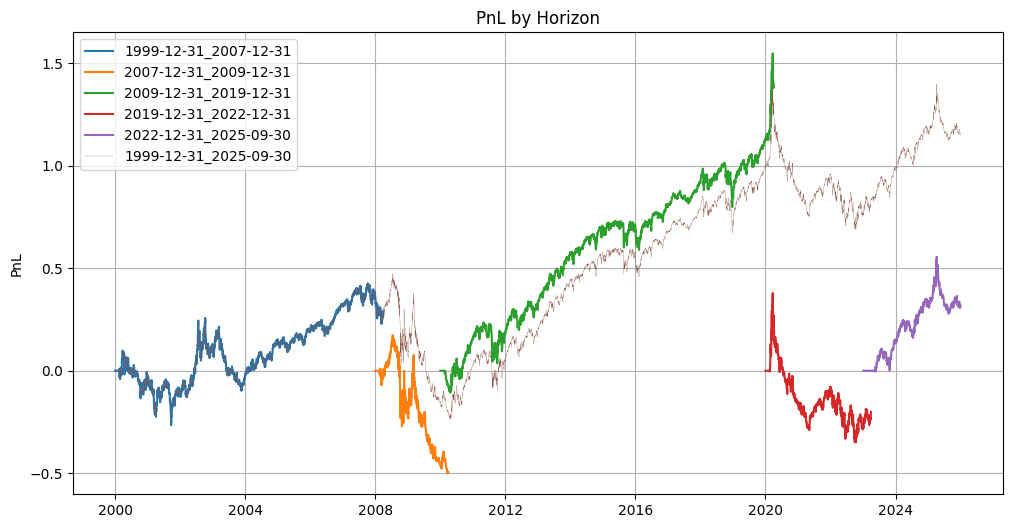

In [51]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2007-12-31"]["rbc_10cal_1999-12-31_2007-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="1999-12-31_2007-12-31"
)

ax1.plot(
    results["2007-12-31_2009-12-31"]["rbc_10cal_2007-12-31_2009-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2007-12-31_2009-12-31"
)

ax1.plot(
    results["2009-12-31_2019-12-31"]["rbc_10cal_2009-12-31_2019-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2009-12-31_2019-12-31"
)

ax1.plot(
    results["2019-12-31_2022-12-31"]["rbc_10cal_2019-12-31_2022-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2019-12-31_2022-12-31"
)

ax1.plot(
    results["2022-12-31_2025-09-30"]["rbc_10cal_2022-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2022-12-31_2025-09-30"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="1999-12-31_2025-09-30",
    linewidth=0.2
)

ax1.set_ylabel("PnL")
ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="best")

plt.title("PnL by Horizon")
plt.show()

In [52]:
hybrid_1_s = results["1999-12-31_2007-12-31"]["rbc_10cal_1999-12-31_2007-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"].copy()

In [53]:
hybrid_2_s = results["2007-12-31_2009-12-31"]["rbc_10cal_2007-12-31_2009-12-31_30lag"]["strategy"]["pnl_cumsum_momn_SP"].copy()
hybrid_2_s += hybrid_1_s[-1]
hybrid_2_s = hybrid_2_s[hybrid_2_s.index > hybrid_1_s.index[-1]]

In [54]:
hybrid_3_s = results["2009-12-31_2019-12-31"]["rbc_10cal_2009-12-31_2019-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"].copy()
hybrid_3_s += hybrid_2_s[-1]
hybrid_3_s = hybrid_3_s[hybrid_3_s.index > hybrid_2_s.index[-1]]

In [55]:
hybrid_4_s = results["2019-12-31_2022-12-31"]["rbc_10cal_2019-12-31_2022-12-31_30lag"]["strategy"]["pnl_cumsum_momn_SP"].copy()
hybrid_4_s += hybrid_3_s[-1]
hybrid_4_s = hybrid_4_s[hybrid_4_s.index > hybrid_3_s.index[-1]]

In [56]:
hybrid_5_s = results["2022-12-31_2025-09-30"]["rbc_10cal_2022-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"].copy()
hybrid_5_s += hybrid_4_s[-1]
hybrid_5_s = hybrid_5_s[hybrid_5_s.index > hybrid_4_s.index[-1]]

In [57]:
hybrid_s = pd.concat([
    hybrid_1_s,
    hybrid_2_s,
    hybrid_3_s,
    hybrid_4_s,
    hybrid_5_s
])

In [58]:
hybrid_s

Date
1999-12-31    0.000000
2000-01-03    0.000000
2000-01-04    0.000000
2000-01-05    0.000000
2000-01-06    0.000000
                ...   
2025-12-24    2.667660
2025-12-26    2.667965
2025-12-29    2.671457
2025-12-30    2.672833
2025-12-31    2.680190
Length: 6540, dtype: float64

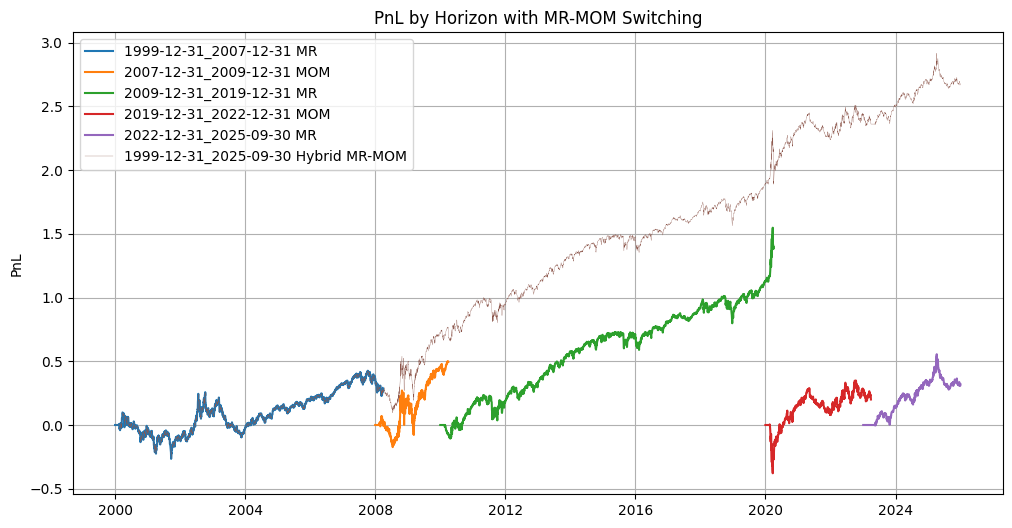

In [59]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2007-12-31"]["rbc_10cal_1999-12-31_2007-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="1999-12-31_2007-12-31 MR"
)

ax1.plot(
    results["2007-12-31_2009-12-31"]["rbc_10cal_2007-12-31_2009-12-31_30lag"]["strategy"]["pnl_cumsum_momn_SP"],
    label="2007-12-31_2009-12-31 MOM"
)

ax1.plot(
    results["2009-12-31_2019-12-31"]["rbc_10cal_2009-12-31_2019-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2009-12-31_2019-12-31 MR"
)

ax1.plot(
    results["2019-12-31_2022-12-31"]["rbc_10cal_2019-12-31_2022-12-31_30lag"]["strategy"]["pnl_cumsum_momn_SP"],
    label="2019-12-31_2022-12-31 MOM"
)

ax1.plot(
    results["2022-12-31_2025-09-30"]["rbc_10cal_2022-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2022-12-31_2025-09-30 MR"
)

ax1.plot(
    hybrid_s,
    label="1999-12-31_2025-09-30 Hybrid MR-MOM",
    linewidth=0.2
)

ax1.set_ylabel("PnL")
ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="best")

plt.title("PnL by Horizon with MR-MOM Switching")
plt.show()

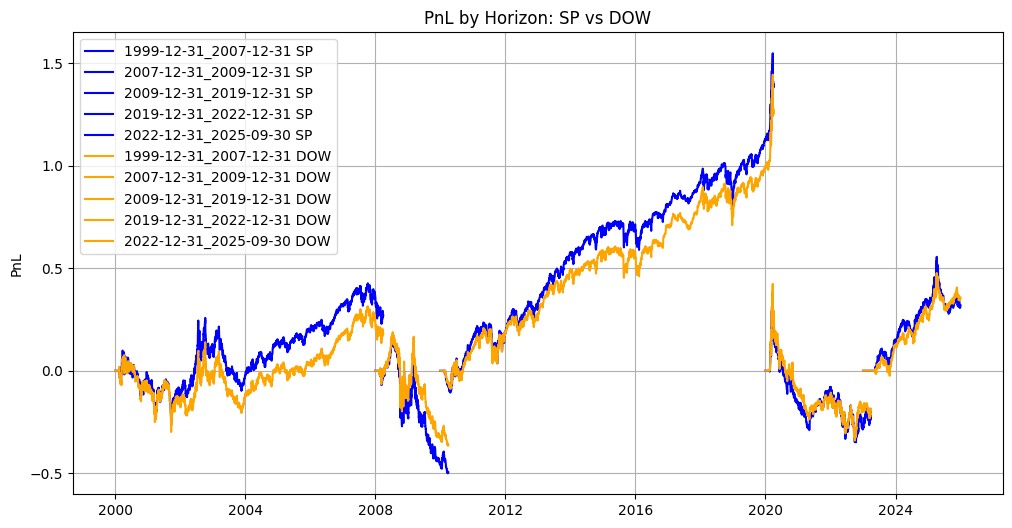

In [60]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2007-12-31"]["rbc_10cal_1999-12-31_2007-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="1999-12-31_2007-12-31 SP",
    color="blue"
)

ax1.plot(
    results["2007-12-31_2009-12-31"]["rbc_10cal_2007-12-31_2009-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2007-12-31_2009-12-31 SP",
    color="blue"
)

ax1.plot(
    results["2009-12-31_2019-12-31"]["rbc_10cal_2009-12-31_2019-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2009-12-31_2019-12-31 SP",
    color="blue"
)

ax1.plot(
    results["2019-12-31_2022-12-31"]["rbc_10cal_2019-12-31_2022-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2019-12-31_2022-12-31 SP",
    color="blue"
)

ax1.plot(
    results["2022-12-31_2025-09-30"]["rbc_10cal_2022-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="2022-12-31_2025-09-30 SP",
    color="blue"
)

ax1.plot(
    results["1999-12-31_2007-12-31"]["rbc_10cal_1999-12-31_2007-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_DOW"],
    label="1999-12-31_2007-12-31 DOW",
    color="orange"
)

ax1.plot(
    results["2007-12-31_2009-12-31"]["rbc_10cal_2007-12-31_2009-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_DOW"],
    label="2007-12-31_2009-12-31 DOW",
    color="orange"
)

ax1.plot(
    results["2009-12-31_2019-12-31"]["rbc_10cal_2009-12-31_2019-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_DOW"],
    label="2009-12-31_2019-12-31 DOW",
    color="orange"
)

ax1.plot(
    results["2019-12-31_2022-12-31"]["rbc_10cal_2019-12-31_2022-12-31_30lag"]["strategy"]["pnl_cumsum_mrn_DOW"],
    label="2019-12-31_2022-12-31 DOW",
    color="orange"
)

ax1.plot(
    results["2022-12-31_2025-09-30"]["rbc_10cal_2022-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_DOW"],
    label="2022-12-31_2025-09-30 DOW",
    color="orange"
)

ax1.set_ylabel("PnL")
ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="best")

plt.title("PnL by Horizon: SP vs DOW")
plt.show()

### Strategy Type

<function matplotlib.pyplot.show(close=None, block=None)>

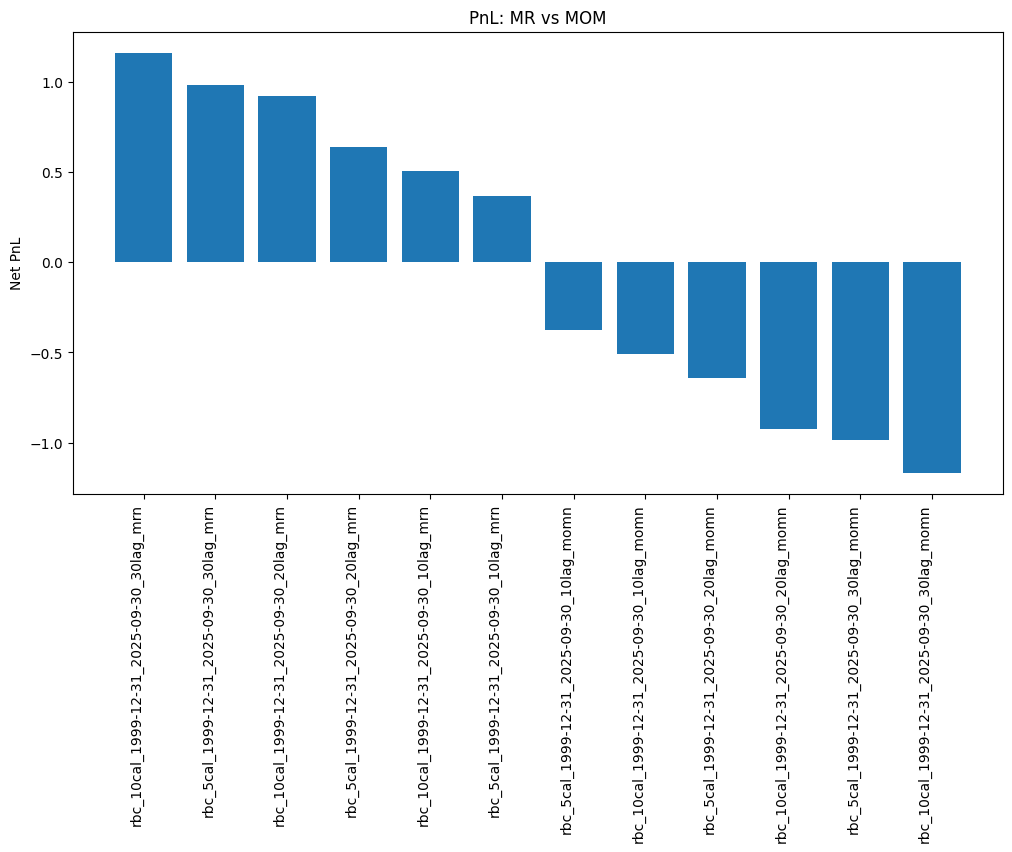

In [75]:
data_bar = main_results_sorted["1999-12-31_2025-09-30"]["pnls_spn_sorted"]
data_bar = [d for d in data_bar if "lev" not in d[0] and "dd" not in d[0] and "bh" not in d[0]]
labels = [row[0] for row in data_bar]
values = [row[1] for row in data_bar]

plt.figure(figsize=(12, 6))
plt.bar(labels, values)

plt.xticks(rotation=90, ha='right')
plt.ylabel("Net PnL")
plt.title("PnL: MR vs MOM")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

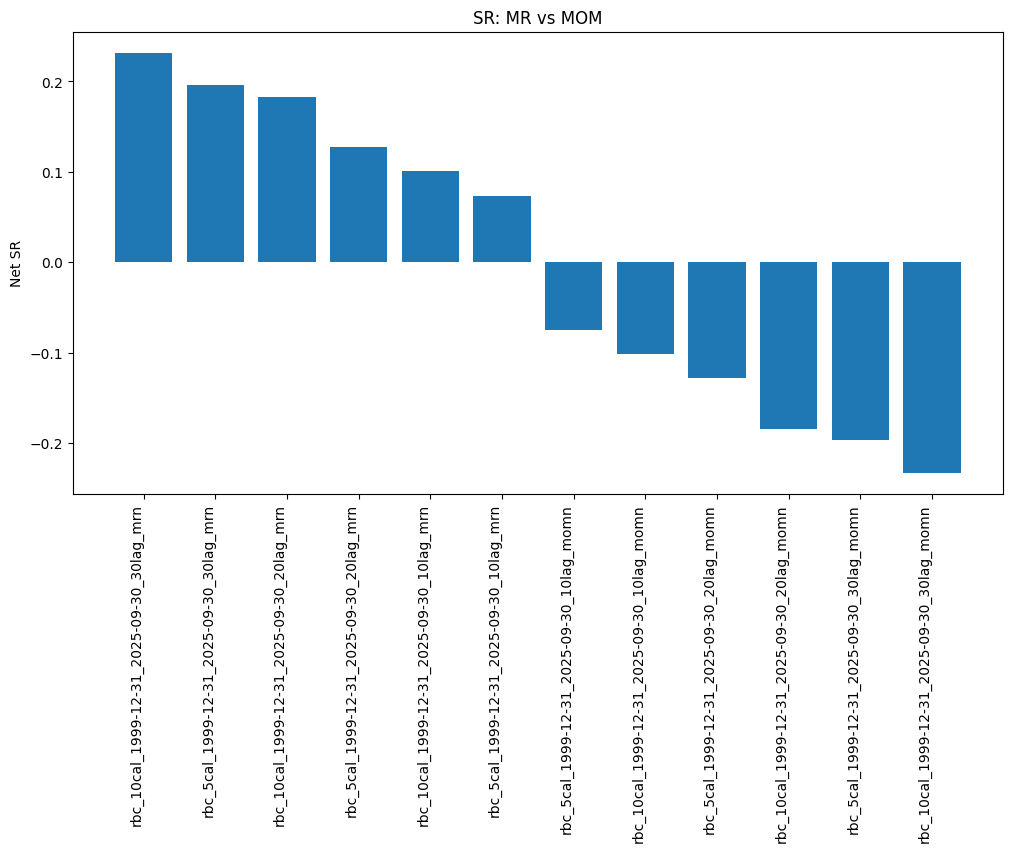

In [74]:
data_bar = main_results_sorted["1999-12-31_2025-09-30"]["srs_spn_sorted"]
data_bar = [d for d in data_bar if "lev" not in d[0] and "dd" not in d[0] and "bh" not in d[0]]
labels = [row[0] for row in data_bar]
values = [row[1] for row in data_bar]

plt.figure(figsize=(12, 6))
plt.bar(labels, values)

plt.xticks(rotation=90, ha='right')
plt.ylabel("Net SR")
plt.title("SR: MR vs MOM")
plt.show

### Data Length

In [90]:
for asset in ["sp"]:
    datalengths_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        datalengths_cmp_list.append(results_comb[
            # (results_comb["Horizon"] == "1999-12-31_2025-09-30") &
            (results_comb["Signal Lag"] == "30b") & 
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MR")
        ])
    datalengths_cmp = pd.concat(datalengths_cmp_list)
    datalengths_cmp.to_csv("results/datalength_comparison_" + asset + "_30b.csv", index=False)

In [91]:
datalengths_cmp

,Model,Data Length,Horizon,Signal Lag,Leverage,Double Down,Strategy Type,Net PnL,Gross PnL,Net SR,Gross SR
17,RBC,10y,1999-12-31_2025-09-30,30b,1,No,MR,1.16,1.16,0.23,0.23
19,RBC,5y,1999-12-31_2025-09-30,30b,1,No,MR,0.98,0.98,0.20,0.20
10,RBC,5y,1999-12-31_2007-12-31,30b,1,No,MR,0.56,0.57,0.39,0.39
18,RBC,10y,1999-12-31_2007-12-31,30b,1,No,MR,0.27,0.27,0.19,0.19
27,RBC,10y,2007-12-31_2009-12-31,30b,1,No,MR,-0.50,-0.50,-0.67,-0.67
30,RBC,5y,2007-12-31_2009-12-31,30b,1,No,MR,-0.56,-0.56,-0.76,-0.76
29,RBC,10y,2009-12-31_2019-12-31,30b,1,No,MR,1.40,1.40,0.81,0.81
32,RBC,20y,2009-12-31_2019-12-31,30b,1,No,MR,1.25,1.25,0.72,0.72
33,RBC,5y,2009-12-31_2019-12-31,30b,1,No,MR,1.18,1.18,0.68,0.68
37,RBC,5y,2019-12-31_2022-12-31,30b,1,No,MR,-0.20,-0.20,-0.25,-0.25


In [92]:
for asset in ["sp"]:
    datalengths_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        datalengths_cmp_list.append(results_comb[
            # (results_comb["Horizon"] == "1999-12-31_2025-09-30") &
            (results_comb["Signal Lag"] == "20b") & 
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MR")
        ])
    datalengths_cmp = pd.concat(datalengths_cmp_list)
    datalengths_cmp.to_csv("results/datalength_comparison_" + asset + "_20b.csv", index=False)

In [93]:
datalengths_cmp

,Model,Data Length,Horizon,Signal Lag,Leverage,Double Down,Strategy Type,Net PnL,Gross PnL,Net SR,Gross SR
20,RBC,10y,1999-12-31_2025-09-30,20b,1,No,MR,0.92,0.92,0.18,0.18
22,RBC,5y,1999-12-31_2025-09-30,20b,1,No,MR,0.64,0.64,0.13,0.13
14,RBC,5y,1999-12-31_2007-12-31,20b,1,No,MR,0.48,0.48,0.33,0.33
21,RBC,10y,1999-12-31_2007-12-31,20b,1,No,MR,0.16,0.16,0.11,0.11
25,RBC,10y,2007-12-31_2009-12-31,20b,1,No,MR,-0.43,-0.43,-0.58,-0.58
28,RBC,5y,2007-12-31_2009-12-31,20b,1,No,MR,-0.50,-0.50,-0.68,-0.68
30,RBC,10y,2009-12-31_2019-12-31,20b,1,No,MR,1.30,1.30,0.75,0.75
31,RBC,20y,2009-12-31_2019-12-31,20b,1,No,MR,1.28,1.28,0.74,0.74
35,RBC,5y,2009-12-31_2019-12-31,20b,1,No,MR,1.05,1.05,0.60,0.60
43,RBC,5y,2019-12-31_2022-12-31,20b,1,No,MR,-0.29,-0.29,-0.35,-0.35


In [94]:
for asset in ["sp"]:
    datalengths_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        datalengths_cmp_list.append(results_comb[
            # (results_comb["Horizon"] == "1999-12-31_2025-09-30") &
            (results_comb["Signal Lag"] == "10b") & 
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MR")
        ])
    datalengths_cmp = pd.concat(datalengths_cmp_list)
    datalengths_cmp.to_csv("results/datalength_comparison_" + asset + "_10b.csv", index=False)

In [95]:
datalengths_cmp

,Model,Data Length,Horizon,Signal Lag,Leverage,Double Down,Strategy Type,Net PnL,Gross PnL,Net SR,Gross SR
23,RBC,10y,1999-12-31_2025-09-30,10b,1,No,MR,0.51,0.51,0.10,0.10
24,RBC,5y,1999-12-31_2025-09-30,10b,1,No,MR,0.37,0.37,0.07,0.07
19,RBC,5y,1999-12-31_2007-12-31,10b,1,No,MR,0.26,0.26,0.18,0.18
26,RBC,10y,1999-12-31_2007-12-31,10b,1,No,MR,-0.16,-0.16,-0.11,-0.11
26,RBC,5y,2007-12-31_2009-12-31,10b,1,No,MR,-0.47,-0.47,-0.64,-0.64
29,RBC,10y,2007-12-31_2009-12-31,10b,1,No,MR,-0.54,-0.54,-0.72,-0.72
27,RBC,20y,2009-12-31_2019-12-31,10b,1,No,MR,1.43,1.43,0.82,0.82
28,RBC,10y,2009-12-31_2019-12-31,10b,1,No,MR,1.42,1.42,0.82,0.82
34,RBC,5y,2009-12-31_2019-12-31,10b,1,No,MR,1.06,1.06,0.61,0.61
40,RBC,5y,2019-12-31_2022-12-31,10b,1,No,MR,-0.26,-0.26,-0.32,-0.32


### Signal Lag

In [100]:
for asset in ["sp"]:
    signallag_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        signallag_cmp_list.append(results_comb[
            (results_comb["Data Length"] == "10y") &
            # (results_comb["Horizon"] == "1999-12-31_2025-09-30") &
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MR")
        ])
    signallag_cmp = pd.concat(signallag_cmp_list)
    signallag_cmp.to_csv("results/signallag_comparison_" + asset + "_mr.csv", index=False)

In [101]:
signallag_cmp

,Model,Data Length,Horizon,Signal Lag,Leverage,Double Down,Strategy Type,Net PnL,Gross PnL,Net SR,Gross SR
17,RBC,10y,1999-12-31_2025-09-30,30b,1,No,MR,1.16,1.16,0.23,0.23
20,RBC,10y,1999-12-31_2025-09-30,20b,1,No,MR,0.92,0.92,0.18,0.18
23,RBC,10y,1999-12-31_2025-09-30,10b,1,No,MR,0.51,0.51,0.10,0.10
18,RBC,10y,1999-12-31_2007-12-31,30b,1,No,MR,0.27,0.27,0.19,0.19
21,RBC,10y,1999-12-31_2007-12-31,20b,1,No,MR,0.16,0.16,0.11,0.11
26,RBC,10y,1999-12-31_2007-12-31,10b,1,No,MR,-0.16,-0.16,-0.11,-0.11
25,RBC,10y,2007-12-31_2009-12-31,20b,1,No,MR,-0.43,-0.43,-0.58,-0.58
27,RBC,10y,2007-12-31_2009-12-31,30b,1,No,MR,-0.50,-0.50,-0.67,-0.67
29,RBC,10y,2007-12-31_2009-12-31,10b,1,No,MR,-0.54,-0.54,-0.72,-0.72
28,RBC,10y,2009-12-31_2019-12-31,10b,1,No,MR,1.42,1.42,0.82,0.82


In [103]:
for asset in ["sp"]:
    signallag_cmp_list = []
    for results_comb in results_comb_dict[asset]:
        signallag_cmp_list.append(results_comb[
            (results_comb["Data Length"] == "10y") &
            # (results_comb["Horizon"] == "1999-12-31_2025-09-30") &
            (results_comb["Leverage"] == 1) & 
            (results_comb["Double Down"] == "No") & 
            (results_comb["Strategy Type"] == "MOM")
        ])
    signallag_cmp = pd.concat(signallag_cmp_list)
    signallag_cmp.to_csv("results/signallag_comparison_" + asset + "_mom.csv", index=False)

In [104]:
signallag_cmp

,Model,Data Length,Horizon,Signal Lag,Leverage,Double Down,Strategy Type,Net PnL,Gross PnL,Net SR,Gross SR
26,RBC,10y,1999-12-31_2025-09-30,10b,1,No,MOM,-0.51,-0.51,-0.10,-0.10
29,RBC,10y,1999-12-31_2025-09-30,20b,1,No,MOM,-0.92,-0.92,-0.18,-0.18
32,RBC,10y,1999-12-31_2025-09-30,30b,1,No,MOM,-1.17,-1.16,-0.23,-0.23
22,RBC,10y,1999-12-31_2007-12-31,10b,1,No,MOM,0.16,0.16,0.11,0.11
27,RBC,10y,1999-12-31_2007-12-31,20b,1,No,MOM,-0.16,-0.16,-0.11,-0.11
30,RBC,10y,1999-12-31_2007-12-31,30b,1,No,MOM,-0.27,-0.27,-0.19,-0.19
19,RBC,10y,2007-12-31_2009-12-31,10b,1,No,MOM,0.54,0.54,0.72,0.72
21,RBC,10y,2007-12-31_2009-12-31,30b,1,No,MOM,0.50,0.50,0.67,0.67
23,RBC,10y,2007-12-31_2009-12-31,20b,1,No,MOM,0.43,0.43,0.58,0.58
42,RBC,10y,2009-12-31_2019-12-31,20b,1,No,MOM,-1.30,-1.30,-0.75,-0.75


### Leverage and Doubling Down

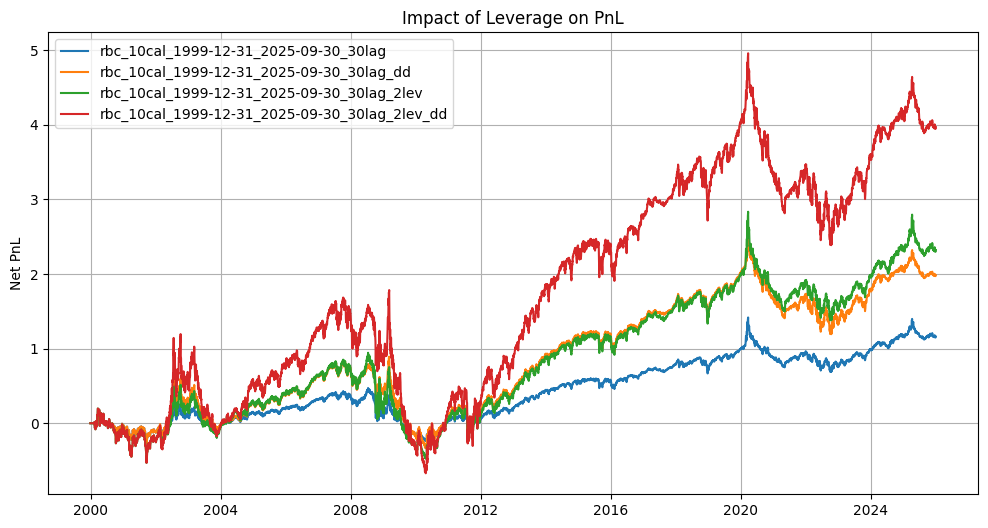

In [109]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag_dd"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag_dd"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag_2lev"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag_2lev"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd"
)

ax1.set_ylabel("Net PnL")
ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="best")

plt.title("Impact of Leverage on PnL")
plt.show()

### BH

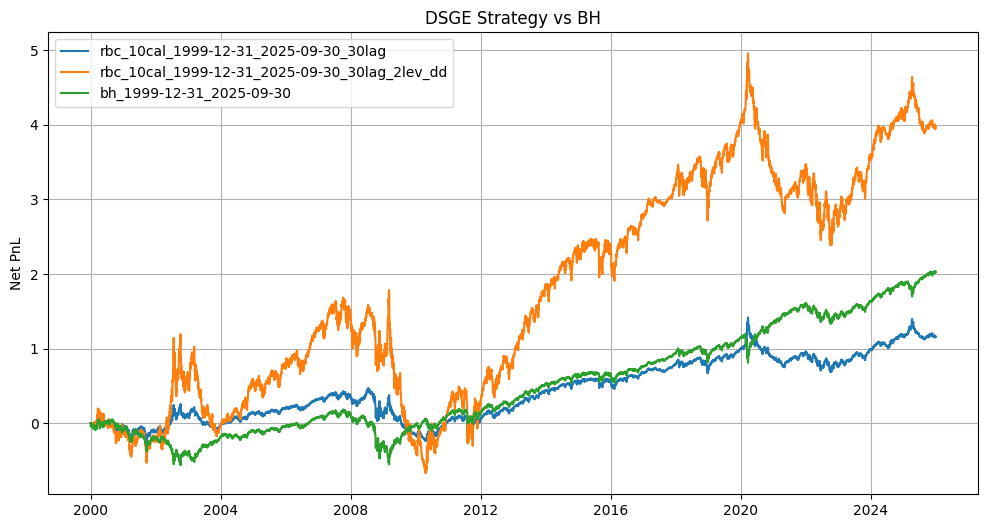

In [110]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis: PnL
ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd"]["strategy"]["pnl_cumsum_mrn_SP"],
    label="rbc_10cal_1999-12-31_2025-09-30_30lag_2lev_dd"
)

ax1.plot(
    results["1999-12-31_2025-09-30"]["bh_1999-12-31_2025-09-30"]["strategy"]["pnl_cumsum_SP"],
    label="bh_1999-12-31_2025-09-30"
)

ax1.set_ylabel("Net PnL")
ax1.grid(True)

# Combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()

ax1.legend(lines_1, labels_1, loc="best")

plt.title("DSGE Strategy vs BH")
plt.show()